Main Data:
   valence  year  acousticness  \
0   0.0594  1921         0.982   
1   0.9630  1921         0.732   

                                             artists  danceability  \
0  ['Sergei Rachmaninoff', 'James Levine', 'Berli...         0.279   
1                                     ['Dennis Day']         0.819   

   duration_ms  energy  explicit                      id  instrumentalness  \
0       831667   0.211         0  4BJqT0PrAfrxzMOxytFOIz             0.878   
1       180533   0.341         0  7xPhfUan2yNtyFG0cUWkt8             0.000   

   key  liveness  loudness  mode  \
0   10     0.665   -20.096     1   
1    7     0.160   -12.441     1   

                                                name  popularity release_date  \
0  Piano Concerto No. 3 in D Minor, Op. 30: III. ...           4         1921   
1                            Clancy Lowered the Boom           5         1921   

   speechiness   tempo  
0       0.0366  80.954  
1       0.4150  60.936  

Genre Data:

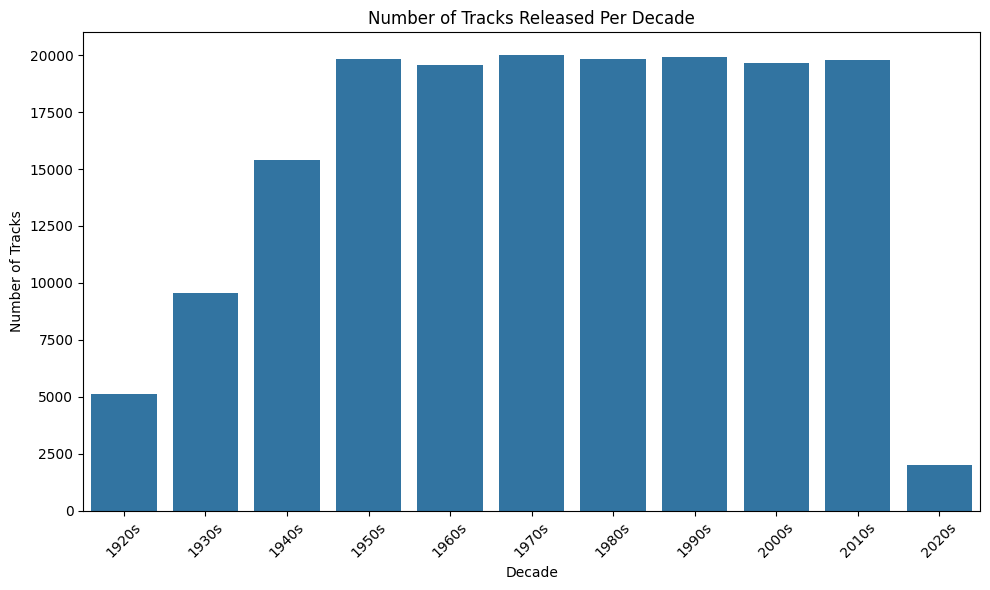

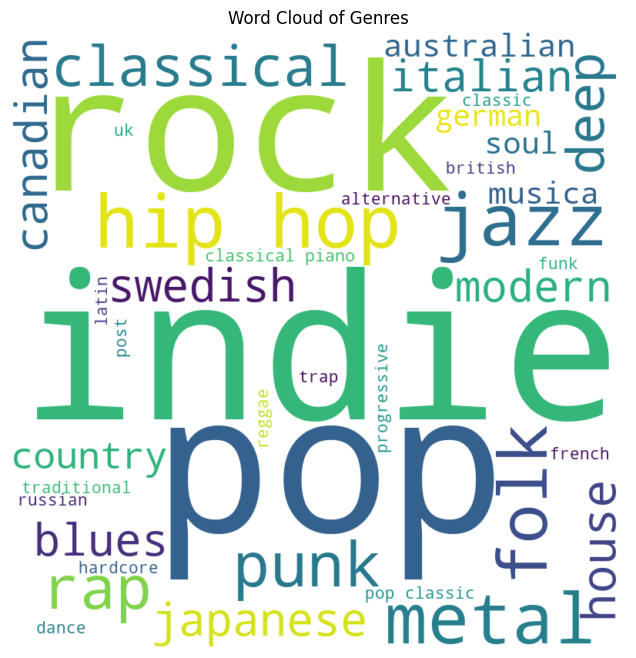

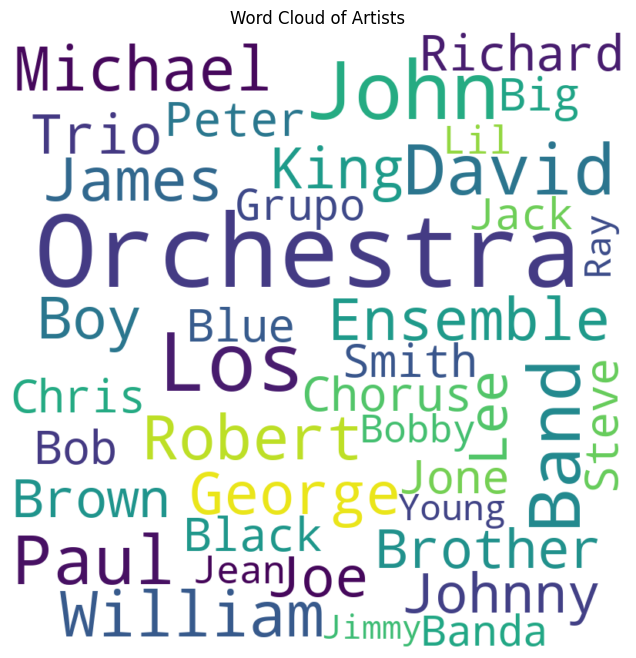


Top 10 Artists with Most Songs:
artists
"Cats" 1981 Original London Cast    1
Pierre Dac                          1
Passafire                           1
Pase Rock                           1
Pascal Rogé                         1
Pascal Devoyon                      1
Pascal Bournet                      1
Parvez Kapadia                      1
Parvati Khan                        1
Parv0                               1
Name: count, dtype: int64


In [2]:
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from wordcloud import WordCloud, STOPWORDS

# -------------------------
# Phase 1: Load & Prepare Data
# -------------------------

# Load datasets
data = pd.read_csv('data.csv')

genre_data = pd.read_csv('data_by_genres.csv')

year_data = pd.read_csv('data_by_year.csv')

artist_data = pd.read_csv('data_by_artist.csv')

# Display first 2 rows
print("Main Data:")
print(data.head(2))
print("\nGenre Data:")
print(genre_data.head(2))
print("\nYear Data:")
print(year_data.head(2))
print("\nArtist Data:")
print(artist_data.head(2))

# Display info
print("\nInfo for Main Data:")
print(data.info())
print("\nInfo for Genre Data:")
print(genre_data.info())

# Add a 'decade' column to the main dataset
data['decade'] = data['year'].apply(lambda x: f"{int(x)//10*10}s" if pd.notnull(x) else 'Unknown')

# -------------------------
# Phase 2: Visualizations
# -------------------------

# 1. Count plot: Tracks per decade
plt.figure(figsize=(10, 6))
sns.countplot(x='decade', data=data, order=sorted(data['decade'].unique()))
plt.title('Number of Tracks Released Per Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Tracks')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Line plot: Trends of sound features over years
sound_features = ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'valence']
fig1 = px.line(year_data, x='year', y=sound_features, title='Trend of Various Sound Features Over Decades')
fig1.show()

# 3. Line plot: Loudness over years
fig2 = px.line(year_data, x='year', y='loudness', title='Trend of Loudness Over Decades')
fig2.show()

# 4. Top 10 genres by popularity (or count)
if 'popularity' in genre_data.columns:
    top10_genres = genre_data.groupby('genres').mean(numeric_only=True).sort_values(by='popularity', ascending=False).head(10).reset_index()
else:
    top10_genres = genre_data['genres'].value_counts().head(10).reset_index()
    top10_genres.columns = ['genres', 'count']

# If sound feature columns exist, plot them
sound_features_for_genres = ['valence', 'energy', 'danceability', 'acousticness']
if all(feature in genre_data.columns for feature in sound_features_for_genres):
    genre_agg = genre_data.groupby('genres')[sound_features_for_genres].mean().loc[top10_genres['genres']].reset_index()
    fig3 = px.bar(
        genre_agg,
        x='genres',
        y=sound_features_for_genres,
        barmode='group',
        title='Trend of Sound Features Over Top 10 Genres'
    )
    fig3.show()

# 5. Word cloud for genres
comment_words = ' '.join(genre_data['genres'].dropna().astype(str).tolist())
wordcloud_genres = WordCloud(
    width=800, height=800, background_color='white',
    stopwords=STOPWORDS, max_words=40, min_font_size=10
).generate(comment_words)

plt.figure(figsize=(8, 8))
plt.imshow(wordcloud_genres, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Genres')
plt.show()

# 6. Word cloud for artists
comment_words_artists = ' '.join(artist_data['artists'].dropna().astype(str).tolist())
wordcloud_artists = WordCloud(
    width=800, height=800, background_color='white',
    stopwords=STOPWORDS, max_words=40, min_word_length=3, min_font_size=10
).generate(comment_words_artists)

plt.figure(figsize=(8, 8))
plt.imshow(wordcloud_artists, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Artists')
plt.show()

# 7. Top 10 artists with most songs
top10_artists = artist_data['artists'].value_counts().head(10)
print("\nTop 10 Artists with Most Songs:")
print(top10_artists)
